In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fsl_mrs.utils.synthetic import synthetic_spectra_from_model
from kinetispect.physio_noise import add_b0_drift, add_physiological_noise
from kinetispect.waterbold import simulate_bold_timeseries, apply_waterbold_referencing

# --- Parameters ---
n_acq = 150
tr_s  = 2.0

# --- Step 1: FSL-MRS synthetic data ---
# We need a basis file and config file from the fMRS demo
import os
demo_dir = os.path.expanduser("~/spise/fsl_mrs_fmrs_demo")
print(os.listdir(demo_dir))

['gen_and_fit_window_avg_data.ipynb', 'generate_data.ipynb', 'bednarik_table_1.csv', 'second_level_files', 'README.md', 'first_level_fit_low_res_demo.ipynb', 'group_results', 'second_level_analysis.ipynb', 'basis', '.git', '.ipynb_checkpoints', 'full_fit_setup.ipynb', 'designmat.csv', '.gitattributes', 'first_level_fit.py', 'LICENSE', '.gitignore', 'simulated_data', 'windowed_avg_results', 'extras', 'main_demo.ipynb', 'first_level_results', 'fmrs_model.py']


In [2]:
print(os.listdir(os.path.join(demo_dir, 'basis')))

['NAAG.json', 'Tau.json', 'NAA.json', 'Gln.json', 'Cr.json', 'Asc.json', 'GABA.json', 'GPC.json', 'Glu.json', 'Scyllo.json', 'GSH.json', 'Mac.json', 'PCh.json', 'PE.json', 'Asp.json', 'Glc.json', 'Lac.json', 'PCr.json', 'Ins.json']


In [3]:
with open(os.path.join(demo_dir, 'fmrs_model.py')) as f:
    print(f.read())

from numpy import dot

# Parameter - functional relationships
Parameters = {
    'conc'     : {'dynamic': 'model_glm', 'params': [f'beta{i}' for i in range(4)]},
    'gamma'    : 'fixed',
    'sigma'    : {'dynamic': 'model_glm', 'params': [f'beta{i}' for i in range(4)]},
    'eps'      : 'fixed',
    'baseline' : 'fixed',
    'Phi_0'    : 'fixed',
    'Phi_1'    : 'fixed'}

# Bounds on free fitted parameters
Bounds = {
    'gamma': (0, None),
    'beta3': (0, None)}


# Dynamic models
def model_glm(p, t):
    return dot(t, p)


# Dynamic model gradients
def model_glm_grad(p, t):
    return t.T



In [4]:
import pandas as pd
dm = pd.read_csv(os.path.join(demo_dir, 'designmat.csv'))
print(dm.shape)
print(dm.head())

(63, 4)
   0.0  0.0.1  -0.49999999999999983  1.0
0  0.0    0.0             -0.484127  1.0
1  0.0    0.0             -0.468254  1.0
2  0.0    0.0             -0.452381  1.0
3  0.0    0.0             -0.436508  1.0
4  0.0    0.0             -0.420635  1.0


n_acq=63, design matrix shape=(63, 4)
Mac not in standard concentrations. Setting to random between 1 and 5.
Generated 63 MRS objects
FID shape: (2048,)
B0 drift range: -0.71 to 3.34 Hz
Physiological noise added
Linewidth change range: -0.014 to 0.005 Hz


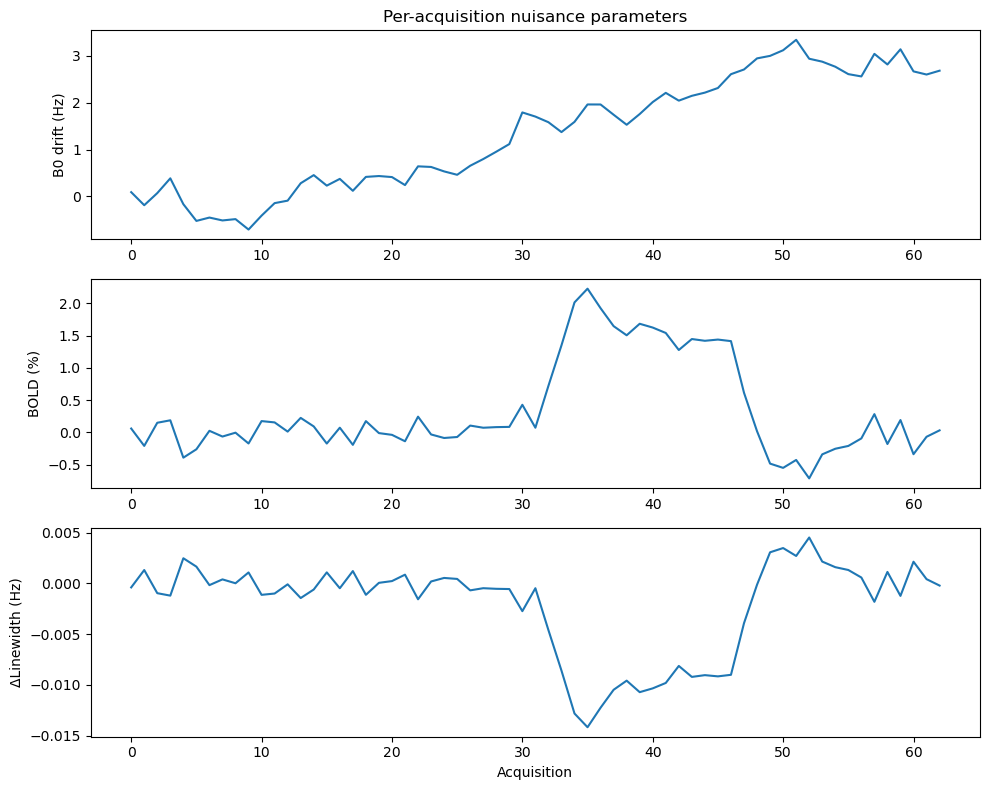

Done — plot saved to results/


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from fsl_mrs.utils.synthetic import synthetic_spectra_from_model
from kinetispect.physio_noise import add_b0_drift, add_physiological_noise
from kinetispect.waterbold import simulate_bold_timeseries, apply_waterbold_referencing

demo_dir = os.path.expanduser("~/spise/fsl_mrs_fmrs_demo")
basis_dir = os.path.join(demo_dir, "basis")
config_file = os.path.join(demo_dir, "fmrs_model.py")

# --- Load the design matrix (defines time_var shape) ---
dm = pd.read_csv(os.path.join(demo_dir, "designmat.csv")).values
n_acq = dm.shape[0]   # 63
tr_s  = 2.0
print(f"n_acq={n_acq}, design matrix shape={dm.shape}")

# --- Step 1: FSL-MRS synthetic data ---
mrs_list, vm, true_params = synthetic_spectra_from_model(
    config_file   = config_file,
    time_var      = dm,          # 63×4 design matrix
    basis_file    = basis_dir,
    noisecovariance = [[0.05]],
    bandwidth     = 4000,
    points        = 2048,
)
print(f"Generated {len(mrs_list)} MRS objects")
print(f"FID shape: {mrs_list[0].FID.shape}")

# --- Step 2: Add B0 drift ---
mrs_list, freq_shifts = add_b0_drift(
    mrs_list,
    drift_rate_hz_per_min=1.0,
    random_walk_std_hz=0.3,
    tr_s=tr_s,
    seed=42,
)
print(f"B0 drift range: {freq_shifts.min():.2f} to {freq_shifts.max():.2f} Hz")

# --- Step 3: Add physiological noise ---
mrs_list = add_physiological_noise(
    mrs_list,
    cardiac_bpm=72,
    resp_bpm=15,
    tr_s=tr_s,
    seed=42,
)
print("Physiological noise added")

# --- Step 4: WaterBOLD referencing ---
bold_pct = simulate_bold_timeseries(
    n_acq,
    tr_s=tr_s,
    block_onsets_s=[60.0],
    seed=42,
)
mrs_list, lw_change = apply_waterbold_referencing(
    mrs_list,
    bold_pct=bold_pct,
    te_ms=30.0,
)
print(f"Linewidth change range: {lw_change.min():.3f} to {lw_change.max():.3f} Hz")

# --- Quick sanity plot ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].plot(freq_shifts)
axes[0].set_ylabel("B0 drift (Hz)")
axes[0].set_title("Per-acquisition nuisance parameters")

axes[1].plot(bold_pct * 100)
axes[1].set_ylabel("BOLD (%)")

axes[2].plot(lw_change)
axes[2].set_ylabel("ΔLinewidth (Hz)")
axes[2].set_xlabel("Acquisition")

plt.tight_layout()
plt.savefig("../results/phase1_nuisance_check.png", dpi=150)
plt.show()
print("Done — plot saved to results/")